In [1]:
### TO RUN
import os

import matplotlib.pyplot as plt
import numpy as np
import time
import pandas as pd
from IPython.display import Markdown, display


"Machine learning tools"
import pickle

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import KFold
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier


from classification.datasets import Dataset
from classification.utils.audio_student import AudioUtil, Feature_vector_DS
from classification.utils.plots import (
    plot_decision_boundaries,
    plot_specgram,
    show_confusion_matrix,
)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from classification.utils.utils import accuracy

In [2]:
np.random.seed(0)

Useful functions to select, read and play the dataset sounds are provided in ``classification/utils/audio_student.py``. <br>

As for the H1, you will have to fill some short pieces of code, as well as answer some questions. We already created cells for you to answer the questions to ensure you don't forget it ;). <br>
You will find the zones to be briefly filled  with a ``### TO COMPLETE`` in the cells below.

<font size=6 color=#009999> 2. Training and Evaluating models on audio signals [~1h30-2h] </font> <br>

In [3]:
### TO RUN
dataset = Dataset()
classnames = dataset.list_classes()

print("\n".join(classnames))

background
birds
chainsaw
fire
fireworks
gunshot
handsaw
helicopter


We will only keep 5 class for this notebook:
- birds
- chainsaw
- fire
- handsaw
- helicopter

The classes used in the contest will be different.

In [4]:
dataset.remove_class("background")
dataset.remove_class("fireworks")
dataset.remove_class("gunshot")
classnames = dataset.list_classes()

print("\n".join(classnames))

birds
chainsaw
fire
handsaw
helicopter


In [5]:
### TO RUN
fm_dir = "data/feature_matrices/"  # where to save the features matrices
model_dir = "data/models/"  # where to save the models
os.makedirs(fm_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

In H1, it was not made explicit what we choose as input for the classification model, a.k.a. ``feature vector`` (it was shown in the illustration). <br>
The objective is, on the transmitter side, to compute a feature vector containing enough information about the audio signal we want to classify, but not too much in order to limit the data which has to be transmitted wirelessly. This is why in H1 we implemented the ``Hz2Mel`` conversion: a very simple compression of the frequency content. <br>
The feature vector we will use here simply consists in taking the first 20 columns of the melspectrogram, corresponding to ~1s, then reshaping it as a vector. This means each feature vector contains ``400`` coefficients, with 20 columns of 20 mels each.  <br>

Once the feature vector has been recovered on the receiver side, we can apply any computation on it to guess the right class this sound belongs to. Today, we will simply reuse the simple KNN and LDA classifiers and look at what we already get. 

<font size=3 color=#FF0000> Important :</font> <br>
The analyses that follow are given as food for thoughts. They are not given as step by step improvements of the classifier.

<font size=5 color=#009999> 2.1. Creation of the dataset </font> <br>

``Feature_vector_DS`` is a class defined in ``classification/utils/audio_student.py``. <br>
The functions ``__len__`` and ``__getitem__`` are implemented, meaning you can call :
- ``len(myds)`` to get the number of sounds in it.
- ``myds[classname,j]`` to get the melspectrogram of the ``j``-th sound from class ``classname``. <br>

Two other useful functions are provided:
- ``get_audiosignal`` returning the temporal audiosignal at the specified index.
- ``display`` playing the sound and showing the associated mel-spectrogram at the specified index.

<font size=3 color=#FF0000> Important :</font> <br>
Before being able to run the cells below, you will have to reuse your functions from H1 to fill the missing lines in ``audio_student.py`` at ``###TO COMPLETE`` locations.

Moreover, you have to restart your python kernel for any change to those imported files to be taken into account. This can be done by pressing 》which stops the kernel and tries to run each cell sequentially.

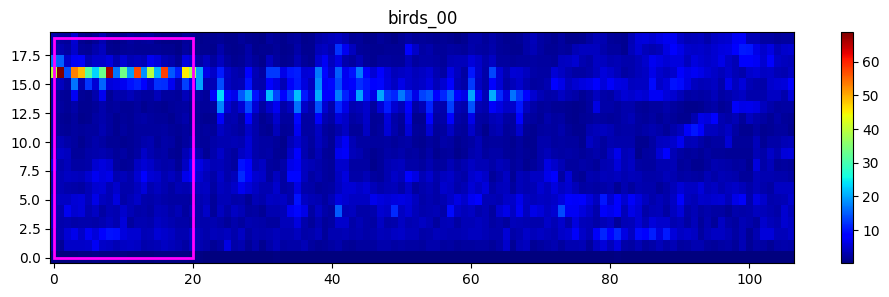

In [6]:
### TO RUN

"Creation of the dataset"
myds = Feature_vector_DS(dataset, Nft=512, nmel=20, duration=950, step=np.inf)

"Some attributes..."
myds.nmel
myds.duration
myds.sr
myds.data_aug
myds.ncol


idx = 0
myds.display(["birds", idx], show_features=True)

### Questions:
The magenta boxes shown in the graph shows the part of the spectrogram that will be actually used as feature.

- Now, in the Feature_vectore_DS intialization, change the step value to 40, 20 and 1. How does this impact the dataset that will be generated?
- Analyze the pros and cons of each value.
- Where can you do your train-test split in each case?

Set step back to np.inf for the rest of this notebook.

<div class="alert alert-info">

Pour faire simple, la première box mauve commence en 0 et il y a un écart de "step" avec la début de la seconde donc:

quand step = np.inf: il n'y a qu'une box mauve de 0 à 20 --> peu de données sur lesquelles entraîner les données, grand risque d'overfitting

quand step = 40, la première est de 0 à 20, la seconde de 40 à à 60, la troisième de 80 à 100 ...) --> on a déjà plus de données pour s'entraîner

quand step = 20, les box se suivent l'une après l'autre sans écart entre elles --> correspond en gros à une analyse de tout le spectrograme

quand step = 1, les box se chevauchent les unes sur les autres --> données redondantes

</div>

In [7]:
### TO RUN
X, y = myds.get_feature_vectors()
np.save(fm_dir + "feature_matrix_2D.npy", X)
np.save(fm_dir + "labels.npy", y)

# X = np.load(fm_dir+"feature_matrix_2D.npy")
# y = np.load(fm_dir+"labels.npy")

print(f"Shape of the feature matrix : {X.shape}")
print(f"Number of labels : {len(y)}")

print(
    "Remember the convention shown for the toy example, the feature vectors are arranged on the rows."
)


Shape of the feature matrix : (200, 400)
Number of labels : 200
Remember the convention shown for the toy example, the feature vectors are arranged on the rows.


You might notice that ``feature_matrix_2D.npy`` has been saved in ``data/feature_matrices/`` and can now be loaded instead of recomputing it at every run.

<font size=5 color=#009999> 2.2. First audio classification, metrics and dataset splitting </font> <br>

For now we have only prepared the dataset, it remains to feed it to the classifiers. <br>

In [8]:
### TO RUN
K = 6  # Number of neighbours for the KNN
model_knn = KNeighborsClassifier(
    n_neighbors=K, weights="distance", algorithm="auto", metric="minkowski"
)  # We explicitly write the default parameters of this KNN classifier once so that you know they exist and can be changed

model_lda = LDA(
    solver="svd",
    shrinkage=None,
    priors=None,
    n_components=None,
    store_covariance=False,
    tol=0.0001,
    covariance_estimator=None,
)  # We explicitly write the default parameters of this LDA classifier once so that you know they exist and can be changed

As for the toy example, we keep the ``accuracy`` as metric and the ``confusion matrix`` as visualization. <br>

Note that here we are not especially interested in a model selection hence we only split the dataset in training and testing parts but we don't split the training set in learning/validation parts. The models are trained on the entire training set.

Shape of the training matrix : (140, 400)
Number of training labels : 140
Accuracy of KNN with fixed train/validation sets : 58.3%


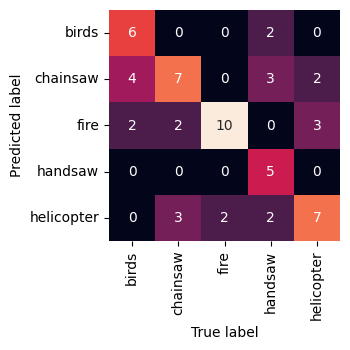

Accuracy of LDA with fixed train/validation sets : 33.3%


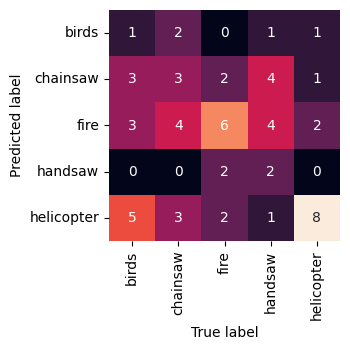

In [9]:
### TO RUN
"Shuffle then split the dataset into training and testing subsets"
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=1
)  # random_state=1
print(f"Shape of the training matrix : {X_train.shape}")
print(f"Number of training labels : {len(y_train)}")

model_knn.fit(X_train, y_train)
model_lda.fit(X_train, y_train)

prediction_knn = model_knn.predict(X_test)
prediction_lda = model_lda.predict(X_test)
accuracy_knn = accuracy(prediction_knn, y_test)
accuracy_lda = accuracy(prediction_lda, y_test)

print(f"Accuracy of KNN with fixed train/validation sets : {100 * accuracy_knn:.1f}%")
show_confusion_matrix(prediction_knn, y_test, classnames)
print(f"Accuracy of LDA with fixed train/validation sets : {100 * accuracy_lda:.1f}%")
show_confusion_matrix(prediction_lda, y_test, classnames)

**Questions**: 
- What would be the expected accuracy if the label predictions were picked at random?
- What do you observe in this confusion matrix? Run again the cell above, i.e., Reapply the ``train_test_split`` and tell if your observations are robust.

<div class="alert alert-info">

En gros, la fonction train_test_split fait à chaque fois des ensembles de data différents, et donc forcément, on a des résultats un peu différents qui varient un peu entre eux. Pour avoir des résultats fixes afin de pouvoir les comparer, il est intéressant de mettre un random_state.
</div>

Play with the ``classname`` and the index ``idx`` to pick feature vectors in the dataset ``myds``, listen to the audio associated to the feature vector, and check if you would have been able to predict the right class by your own. Then compare with the prediction given by your classifier.

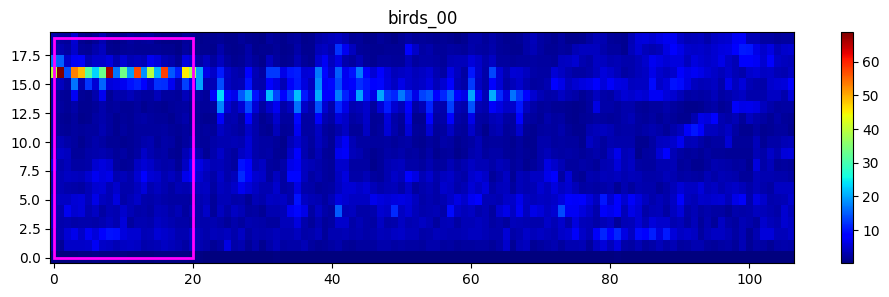

Class predicted by KNN: birds
Class predicted by LDA: chainsaw


In [10]:
### TO RUN
idx = 0
classname = "birds"

# birds
# chainsaw
# fire
# handsaw
# helicopter

myds.display([classname, idx], show_features=True)
thisfv = myds.treat_spec(myds[classname, idx])[0]

# this artefact is necessary because the 'predict' function expects a matrix_like input.
mat = np.zeros((2, len(thisfv)))
mat[0] = thisfv

prediction_knn = model_knn.predict(mat)
prediction_lda = model_lda.predict(mat)

print("Class predicted by KNN:", prediction_knn[0])
print("Class predicted by LDA:", prediction_lda[0])

Furthermore, when training a model and comparing different settings, there is a risk that we will end up choosing optimal parameters that only render good result on our specific case of training and validation set, but ``do not generalize well for additional data``. This is called ``overfitting on the validation set``. To alleviate this, we can perform ``cross-validation (CV)``. A basic approach named ``K-fold CV`` involves partitioning the dataset in ``K`` "folds" (subsets) and repetitvely do the following procedure:

- Train the model using `K-1` folds as the training data.
- Test the model using the last fold as the validation data.

The overall performance on each fold is then averaged to obtain the final performance metrics.

In [11]:
### TO RUN
n_splits = 5
kf = StratifiedKFold(n_splits=n_splits, shuffle=True)

accuracy_knn = np.zeros((n_splits,))
accuracy_lda = np.zeros((n_splits,))
for k, idx in enumerate(kf.split(X_train, y_train)):
    (idx_learn, idx_val) = idx
    model_knn.fit(X_train[idx_learn], y_train[idx_learn])
    prediction_knn = model_knn.predict(X_train[idx_val])
    accuracy_knn[k] = accuracy(prediction_knn, y_train[idx_val])

    model_lda.fit(X_train[idx_learn], y_train[idx_learn])
    prediction_lda = model_lda.predict(X_train[idx_val])
    accuracy_lda[k] = accuracy(prediction_lda, y_train[idx_val])

print(f"Mean accuracy of KNN with 5-Fold CV: {100 * accuracy_knn.mean():.1f}%")
print(
    f"Std deviation in accuracy of KNN with 5-Fold CV: {100 * accuracy_knn.std():.1f}%"
)

print(f"Mean accuracy of LDA with 5-Fold CV: {100 * accuracy_lda.mean():.1f}%")
print(
    f"Std deviation in accuracy of LDA with 5-Fold CV: {100 * accuracy_lda.std():.1f}%"
)

Mean accuracy of KNN with 5-Fold CV: 51.4%
Std deviation in accuracy of KNN with 5-Fold CV: 12.5%
Mean accuracy of LDA with 5-Fold CV: 28.6%
Std deviation in accuracy of LDA with 5-Fold CV: 8.7%


<font size=5 color=#009999> 2.3. Scale mismatch and countermeasure </font> <br>

In real conditions, you will most probably have a different scale between the feature vectors used for training (in simulation) and the ones you feed in your model to make predictions.
This scale mismatch between model training and prediction is difficult to prevent because it depends on multiple factors such as the audio source power, its distance to the microphone, the telecommunication distance. <br>

Below, we illustrate the link between the volume of the audio and its distance to the origin of the feature space. At different emission distances, the exact same sound would be heard at a different volume and the associated feature vector would be located at another position in the *feature space*. Eventually, this would result in a completely different classification, which is undesirable.

<center> <img src="figs/norms.png" alt="" width="350"/> </center>

### Questions:

- How could you avoid this dependency on the volume of the sound?
- What is represented in the hatched centered area? How would you classify feature vectors in this area?

<div class="alert alert-info">

Le cercle hachuré est le cercle du bruit, il ne faut pas normaliser les données où il n'y rien

Pour régler ce problème, on peut standardiser ou normaliser les données (attention normaliser sur [0, 1] ou sur un cercle?)
Ma manière à moi de le comprendre, c'est que c'est la zone où toutes les features se trouverons si on effectue une normalisation de la norme du vecteur (x1, x2) de telle façon à ce que celle-ci ne puisse excéder $\epsilon$

</div>

Play with the ``dB_mismatch`` variable here below and observe its effect on the confusion matrix.

On which part of the dataset are we computing this confusion matrix?

<div class="alert alert-info">

On peut voir que quand on change dB_mismatch, les performances du modèle changent aussi.
En effet, en changeant le volume des données de validation, on s'éloigne des données d'entraînement (qui elles n'ont pas été modifiées) et donc le modèle a plus de mal à bien classer les données et va donc mal les classer.

On calcule la confusion matrix sur le train set
</div>

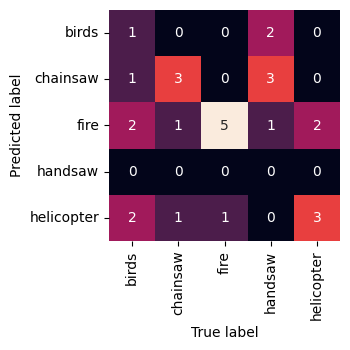

Accuracy of KNN: 42.9%


In [12]:
### TO RUN
dB_mismatch = -0  # Play with this value
X_val_scaled = X_train[idx_val] * 10 ** (-dB_mismatch / 20)

model_knn = KNeighborsClassifier(n_neighbors=10)
model_knn.fit(X_train[idx_learn], y_train[idx_learn])
prediction_knn = model_knn.predict(X_val_scaled)
show_confusion_matrix(prediction_knn, y_train[idx_val], classnames)
accuracy_knn = accuracy(prediction_knn, y_train[idx_val])
print(f"Accuracy of KNN: {100 * accuracy_knn:.1f}%")

The simplest countermeasure we can think of is to normalise the feature vector (i.e. unitize its norm) prior to use, both for training and testing. Remember how this normalization could be visualized in ``hands_on_classif1_toy_student.ipynb`` <br>
Play again with the ``dB_mismatch`` variable here below and observe its effect on the confusion matrix.

<div class="alert alert-info">

On se rend compte qu'avec la normalisation, l'intensité du son ne compte plus
</div>

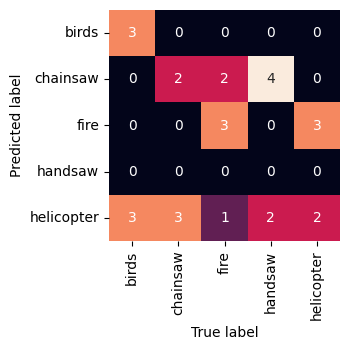

Accuracy of KNN: 35.7%


In [13]:
### TO RUN
dB_mismatch = -0  # Play with this value

X_learn_normalised = X_train[idx_learn] / np.linalg.norm(
    X_train[idx_learn], axis=1, keepdims=True
)
model_knn = KNeighborsClassifier(n_neighbors=10, weights="distance")
model_knn.fit(X_learn_normalised, y_train[idx_learn])

X_val_scaled = X_train[idx_val] * 10 ** (-dB_mismatch / 20)
X_val_normalised = X_val_scaled / np.linalg.norm(X_val_scaled, axis=1, keepdims=True)

prediction_knn = model_knn.predict(X_val_normalised)
show_confusion_matrix(prediction_knn, y_train[idx_val], classnames)
accuracy_knn = accuracy(prediction_knn, y_train[idx_val])
print(f"Accuracy of KNN: {100 * accuracy_knn:.1f}%")

**Question**: 
- What will happen with this normalisation countermeasure when there is no sound around the microphone? Is this desirable? How could you deal with it?

<div class="alert alert-info">

Si le son vaut 0, on aura une division par 0 ce qui n'est pas défini. c'est risqué comme modèle
</div>

<font size=5 color=#009999> 2.4. Dimensionality reduction </font> <br>

It is sometimes good practice to reduce the dimensionality of a signal in order to get the main components of their distribution. A motivation is that usual norms behave counter-inuitively in high dimension. It also further reduces the memory cost of the feature vector. To reduce the dimensionality, we will use the ``Principal component analysis (PCA)`` proposed by sklearn. See the [associated Wikipedia page](https://en.wikipedia.org/wiki/Principal_component_analysis). Recall: the PCA consists in reducing the dimensionality of data vectors encoded in $\boldsymbol X \in \mathbb R^{d\times N}$ to only $p \ll d$ dimensions as

$$
    \boldsymbol Y = \boldsymbol V_p^\top \boldsymbol X \in \mathbb R^{p\times N},
$$

where the SVD of the covariance matrix writes as $\hat{\boldsymbol\Sigma}_{\boldsymbol X} = \frac{1}{d} \boldsymbol{XX}^\top = \boldsymbol{U\Sigma V}^\top$, and $\boldsymbol V_p$ is the subselection of the first $p$ columns of $\boldsymbol V$. 

For our application, reducing the dimensionality of the data can be helpful for compressing the packet size to be transmitted wirelessly. Indeed, once learned during training, $\boldsymbol V_p$ can be hardcoded on the transmitter side.

Starting with a PCA to 2D for visualization, see how hard it is to separate the classes.

Shape of the reduced training matrix : (112, 2)


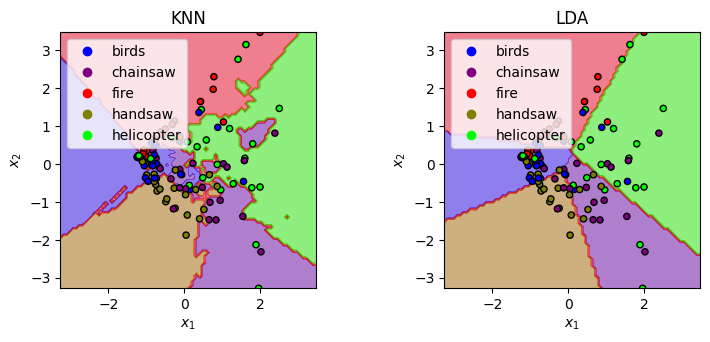

In [14]:
### TO RUN
n = 2  # Number of principal components kept
pca = PCA(n_components=n, whiten=True)
X_learn_reduced = pca.fit_transform(X_train[idx_learn])
X_val_reduced = pca.transform(X_train[idx_val])

print(f"Shape of the reduced training matrix : {X_learn_reduced.shape}")

y_train_num = np.zeros(y_train.shape)
for i, classname in enumerate(classnames):
    y_train_num[y_train == classname] = i

K = 10
model_knn = KNeighborsClassifier(n_neighbors=K)
model_knn.fit(X_learn_reduced, y_train_num[idx_learn])
prediction_knn = model_knn.predict(X_val_reduced)
accuracy_knn = accuracy(prediction_knn, y_train_num[idx_val])

model_lda = LDA()
model_lda.fit(X_learn_reduced, y_train_num[idx_learn])
prediction_lda = model_lda.predict(X_val_reduced)
accuracy_lda = accuracy(prediction_lda, y_train_num[idx_val])


fig = plt.figure()
axs = [fig.add_axes([0.0, 0.0, 0.4, 0.9]), fig.add_axes([0.6, 0.0, 0.4, 0.9])]
plot_decision_boundaries(
    X_learn_reduced,
    y_train_num[idx_learn],
    ax=axs[0],
    model=model_knn,
    legend=classnames,
    title="KNN",
)
plot_decision_boundaries(
    X_learn_reduced,
    y_train_num[idx_learn],
    ax=axs[1],
    model=model_lda,
    legend=classnames,
    title="LDA",
)
plt.show()


**Question**: 
- From the decision boundaries shown here above, can you explain why the ``handsaw`` class is less often chosen than the other classes for the ``KNN`` classifier?

<div class="alert alert-info">

handsaw se trouve plus mêlé aux birds et au chainsaw quand pour LDA
</div>

Shape of the reduced learning matrix : (112, 5)
Accuracy of the KNN : 50.0%


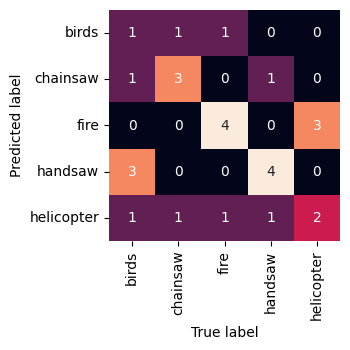

Accuracy of the LDA : 53.6%


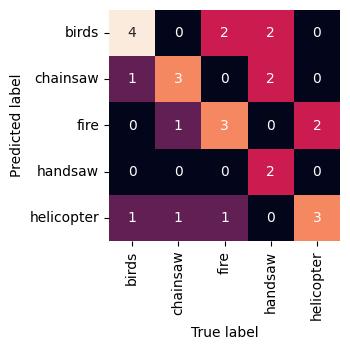

In [15]:
### TO RUN
n = 5  # Number of principal components kept
pca = PCA(n_components=n, whiten=True)
X_learn_reduced = pca.fit_transform(X_train[idx_learn])
X_val_reduced = pca.transform(X_train[idx_val])

print(f"Shape of the reduced learning matrix : {X_learn_reduced.shape}")

K = 10
model_knn = KNeighborsClassifier(n_neighbors=K, weights="distance")
model_knn.fit(X_learn_reduced, y_train[idx_learn])
prediction_knn = model_knn.predict(X_val_reduced)
accuracy_knn = accuracy(prediction_knn, y_train[idx_val])

model_lda = LDA()
model_lda.fit(X_learn_reduced, y_train[idx_learn])
prediction_lda = model_lda.predict(X_val_reduced)
accuracy_lda = accuracy(prediction_lda, y_train[idx_val])

print(f"Accuracy of the KNN : {100 * accuracy_knn:.1f}%")
show_confusion_matrix(prediction_knn, y_train[idx_val], classnames)
print(f"Accuracy of the LDA : {100 * accuracy_lda:.1f}%")
show_confusion_matrix(prediction_lda, y_train[idx_val], classnames)

<font size=5 color=#009999> 2.5. Analysis of the hyperparameters </font> <br>

Finally, we can inspect the influence of ``hyperparameters`` as we did for the toy example. <br>
Let us start by analyzing the influence of the number of neighbours $K$ in the KNN. 

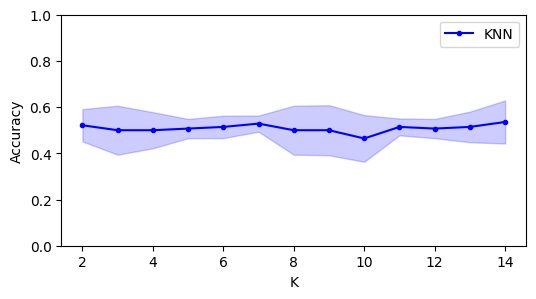

In [16]:
### TO RUN
Ks = np.arange(2, 15, 1)
accuracies_knn = np.zeros((len(Ks), n_splits))
for i, K in enumerate(Ks):
    model_knn = KNeighborsClassifier(n_neighbors=K, weights="distance")
    for k, idx in enumerate(kf.split(X_train, y_train)):
        (idx_learn, idx_val) = idx
        model_knn.fit(X_train[idx_learn], y_train[idx_learn])
        prediction_knn = model_knn.predict(X_train[idx_val])
        accuracies_knn[i, k] = accuracy(prediction_knn, y_train[idx_val])
means_knn = accuracies_knn.mean(axis=1)
stds_knn = accuracies_knn.std(axis=1)

"Plot"
plt.figure(figsize=(6, 3))
plt.plot(Ks, means_knn, ".-b", label="KNN")
plt.fill_between(Ks, means_knn - stds_knn, means_knn + stds_knn, alpha=0.2, color="b")
plt.ylim(0, 1)
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Here we consider both ``K`` and the number of principal components ``n``.

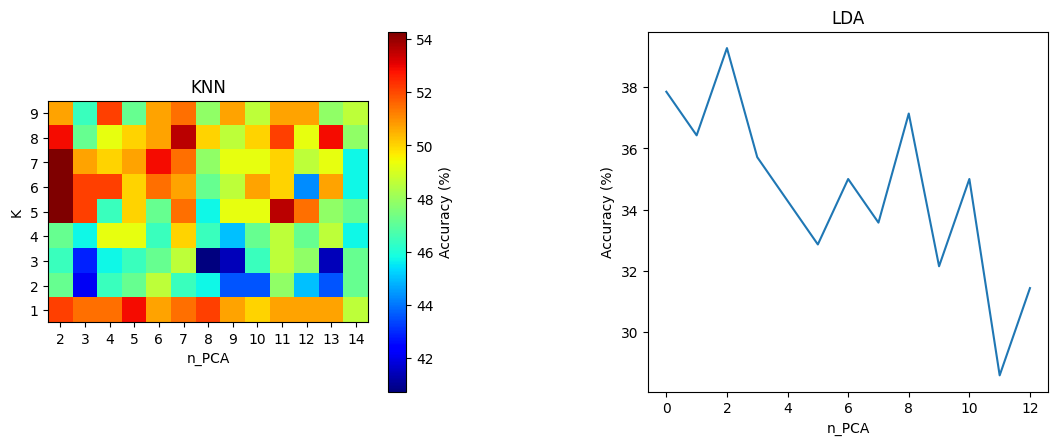

In [17]:
### TO RUN
Ks = np.arange(1, 10)
n_comps = np.arange(2, 15)  # number of principal components kept for the PCA
accuracies_knn = np.zeros((len(Ks), len(n_comps)))
accuracies_lda = np.zeros(len(n_comps))

for j, n in enumerate(n_comps):
    for idx_learn, idx_val in kf.split(X_train, y_train):
        pca = PCA(n_components=n, whiten=True)
        X_learn_reduced = pca.fit_transform(X_train[idx_learn])
        X_val_reduced = pca.transform(X_train[idx_val])
        for i, K in enumerate(Ks):
            model_knn = KNeighborsClassifier(n_neighbors=K)
            model_knn.fit(X_train[idx_learn], y_train[idx_learn])
            prediction_knn = model_knn.predict(X_train[idx_val])
            accuracies_knn[i, j] += accuracy(prediction_knn, y_train[idx_val])

        model_lda = LDA()
        model_lda.fit(X_train[idx_learn], y_train[idx_learn])
        prediction_lda = model_lda.predict(X_train[idx_val])
        accuracies_lda[j] += accuracy(prediction_lda, y_train[idx_val])

accuracies_knn /= n_splits
accuracies_lda /= n_splits

fig = plt.figure(figsize=(10, 4))
axs = [fig.add_axes([0.0, 0.0, 0.4, 0.9]), fig.add_axes([0.6, 0.0, 0.4, 0.9])]

im0 = axs[0].imshow(100 * accuracies_knn, cmap="jet", origin="lower")
cbar = fig.colorbar(im0, ax=axs[0])
cbar.set_label("Accuracy (%)")
axs[0].set_xlabel("n_PCA")
axs[0].set_ylabel("K")
axs[0].set_xticks(list(np.arange(len(n_comps))))
axs[0].set_xticklabels(list(n_comps))
axs[0].set_yticks(list(np.arange(len(Ks))))
axs[0].set_yticklabels(list(Ks))
axs[0].set_title("KNN")

axs[1].plot(accuracies_lda * 100)
axs[1].set_xlabel("n_PCA")
axs[1].set_ylabel("Accuracy (%)")
axs[1].set_title("LDA")
plt.show()

**Question**: 
- Do you observe some dependency of the accuracy on these parameters? If so, which one(s)? If not, discuss what it tells about the considered model. 

<div class="alert alert-info">

On remarque de légères différences, mais elles ne sont pas très grandes, vu les performances éclatées de ces deux modèles et le fait qu'on a du mal à trouver de bons hyperparamètres, il serait judicieux d'essayer d'autres modèles.
</div>

<font size=5 color=#009999> 2.6. Augmenting the data </font> <br>

In order to make our classifier more robust to some common transformations of the audio signal such as ``time shift``, ``AWGN``, or a ``transfer function``, an idea consists in feeding the classifier with such transformations. A popular approach is to create new feature vectors based on transformed versions of the sounds from the original dataset, this is called ``data augmentation``. Data augmentation is also often used when there is few data to train a model. <br>

The functions to augment your data are written in ``utils/audio_student.py``, we already implemented ``time_shift``, ``echo`` and ``spectro_aug_timefreq_masking`` for you. Try to implement ``scaling``, ``add_noise``, ``filter``, ``add_bg`` and even more data augmentation techniques if you want, and check their working in the cell below. <br>

<u>Tip</u>: to avoid restarting the notebook kernel for each modification, you can temporarily insert the ``AudioUtil`` class in a new cell and make your tests until it is working as expected. 

<div class="alert alert-info">

IDEM POUR LA FONCTION FILTER

IDEM POUR ADD BG
</div>

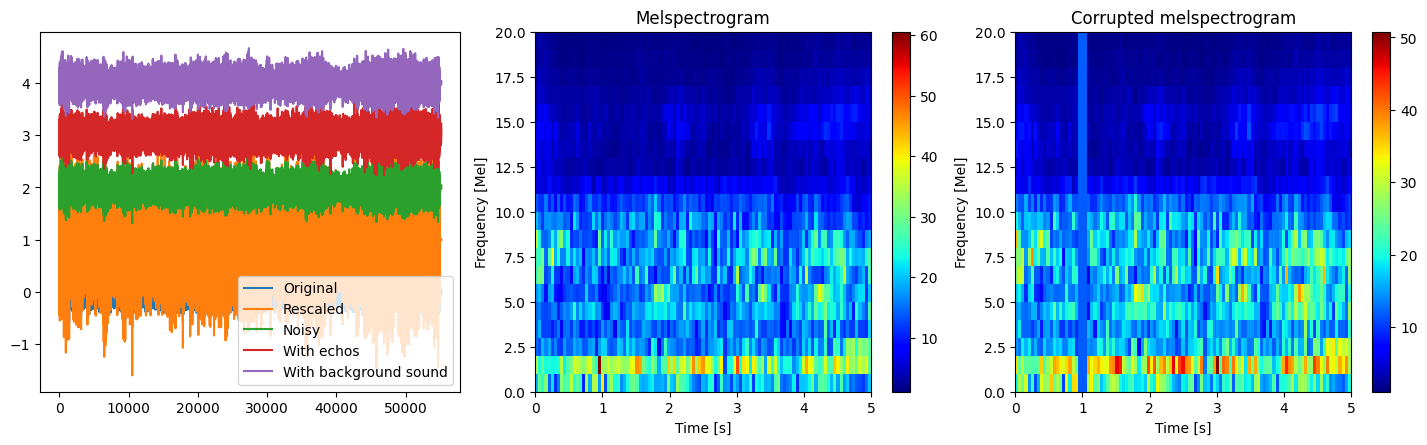

In [18]:
### TO RUN
myds.data_aug = "noise"  # Ensure

cls_index = ["chainsaw", 4]

sound = dataset.__getitem__(cls_index)
name = dataset.__getname__(cls_index)
audio = AudioUtil.open(sound)

AudioUtil.play(audio)
audio2 = AudioUtil.resample(audio, 11025)
audio2 = AudioUtil.pad_trunc(audio2, 5000)

audio3 = AudioUtil.scaling(audio2)
audio4 = AudioUtil.add_noise(audio2, sigma=1e-2)
audio5 = AudioUtil.echo(audio2, 3)
audio6 = AudioUtil.add_bg(audio2, dataset)

melspec = AudioUtil.melspectrogram(audio2, fs2=11025)
melspec2 = AudioUtil.spectro_aug_timefreq_masking(melspec, max_mask_pct=0.1)

"Plot"
fig = plt.figure(figsize=(15, 4))
ax1 = fig.add_axes([0.05, 0.05, 0.28, 0.9])
ax2 = fig.add_axes([0.38, 0.05, 0.28, 0.9])
ax3 = fig.add_axes([0.7, 0.05, 0.28, 0.9])

ax1.plot(audio2[0], label="Original")
ax1.plot(audio3[0] + 1, label="Rescaled")
ax1.plot(audio4[0] + 2, label="Noisy")
ax1.plot(audio5[0] + 3, label="With echos")
ax1.plot(audio6[0] + 4, label="With background sound")
ax1.legend()

plot_specgram(melspec, ax2, is_mel=True, title=name, tf=len(audio2[0]) / audio2[1])
ax2.set_title("Melspectrogram")
plot_specgram(melspec2, ax3, is_mel=True, title=name, tf=len(audio2[0]) / audio2[1])
ax3.set_title("Corrupted melspectrogram")
plt.show()

We can now create a new augmented dataset and observe if the classification results improve. 

In [19]:
### TO RUN
myds.mod_data_aug(["add_bg"])

X_aug, y_aug = myds.get_feature_vectors()

np.save(fm_dir + "feature_matrix_2D_aug.npy", X)
np.save(fm_dir + "labels_aug.npy", y)

# X_aug = np.load(fm_dir+"feature_matrix_2D_aug.npy")
# y_aug = np.load(fm_dir+"labels_aug.npy")


print(f"Shape of the feature matrix : {X_aug.shape}")
print(f"Number of labels : {len(y_aug)}")

Shape of the feature matrix : (400, 400)
Number of labels : 400


Mean accuracy with 5-Fold CV: 57.5%
Std deviation in accuracy with 5-Fold CV: 7.5%


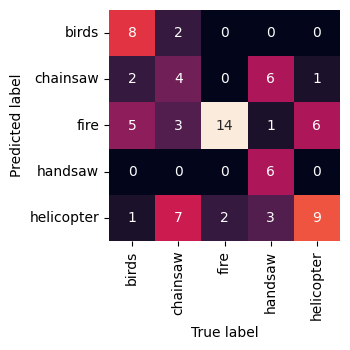

In [20]:
### TO RUN
K = 10  # Number of neighbours
model = KNeighborsClassifier(n_neighbors=K)

accuracy_aug = np.zeros((n_splits,))
for k, idx in enumerate(kf.split(X_aug, y_aug)):
    (idx_train, idx_test) = idx
    model.fit(X_aug[idx_train], y_aug[idx_train])
    prediction_aug = model.predict(X_aug[idx_test])
    accuracy_aug[k] = accuracy(prediction_aug, y_aug[idx_test])

print(f"Mean accuracy with 5-Fold CV: {100 * accuracy_aug.mean():.1f}%")
print(f"Std deviation in accuracy with 5-Fold CV: {100 * accuracy_aug.std():.1f}%")
show_confusion_matrix(prediction_aug, y_aug[idx_test], classnames)

**Questions**:
- Can you see an improvement of the classification result compared to the non augmented dataset? Try to interpret your answer by thinking about the distribution of points in a data space (as with the toy example), what does it imply to augment the data in terms of distribution of points in the data space?
- With the ``add_bg`` augmentation technique, where are the additive background signals coming from? It is a good thing?
- What transformations are most likely to be realistic in your application? What is the most efficient way to integrate these alterations in your classification task? ``Hint``: it does not require augmenting your data in Python.

In [21]:
### TO COMPLETE
# Answer the question above

<font size=5 color=#009999> 2.7. Getting it all together </font> <br>

Now that some aspects to be considered during the model training and analysis have been presented, it remains to train and save a final model that will be used for further predictions.

In [38]:
# [1] Create dataset of feature vectors and split it.
# (optional) with data augmentation
### TO RUN
data_aug = "add_bg"  # None

dataset_own = Dataset()
dataset_own.remove_class("background")
dataset_own.remove_class("fireworks")
dataset_own.remove_class("gunshot")
myds = Feature_vector_DS(
    dataset_own, Nft=512, nmel=20, duration=950, step=1, data_aug=data_aug,
)
X, y = myds.get_feature_vectors()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=1
)

# [2] (optional) Data normalization
X_train_normalised = X_train / np.linalg.norm(X_train, axis=1, keepdims=True)
X_test_normalised = X_test / np.linalg.norm(X_test, axis=1, keepdims=True)


In [40]:
classnames = dataset_own.list_classes()


In [41]:
def KFold_MLPClassifier_print_best_scores(scores, param_for_scores, top_n=5):
    """
    Print the top N best scores from the scores dictionary.
    Inputs:
        scores: Dictionary of scores with parameter combinations as keys.
        param_for_scores: Dictionary mapping keys to parameter combinations.
        top_n: Number of top scores to print.
    """
    sorted_scores = sorted(scores.items(), key=lambda x: x[1])
    print(f"Top {top_n} best scores:")
    for i in range(top_n):
        if i >= len(sorted_scores):
            break
        key, score = sorted_scores[len(sorted_scores) - 1 - i]
        params = param_for_scores[key]
        string_params = f"hidden_layers={params[0]}, activation={params[1]}, data_set_index={params[2]}, n_pca = {params[3]}, pca_model={params[4]}, time={params[5]:.2f}s"
        print(f"Rank {i+1}: Accuracy = {100*score:.4f}%, Parameters = {string_params}")

accuracy_map = []
def KFold_MLPClassifier_tuning(hidden_layer_sizes, activations, tol, n_pca, n_splits=5):
    """
    Perform K-Fold cross-validation to tune MLPClassifier hyperparameters.
    Inputs:
        losses: List of loss functions to try.
        hidden_layer_sizes: List of hidden layer size configurations to try.
        activations: List of activation functions to try.
        tol: Tolerance for optimization.
        features: Dictionary of feature sets to use.
        scale_type: List indicating which scaling types to use ("standardized" and/or "normalized").
    Outputs:
        scores: Dictionary of RMSE scores for each parameter combination.
        param_for_scores: Dictionary mapping keys to parameter combinations.
        X_set: List of training and validation feature sets for each fold.
        y_set: List of training and validation label sets for each fold.
    """

    scores = {}
    param_for_scores = {}
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    X_set = [[]]*n_splits*len(n_pca)
    y_set = [[]]*n_splits*len(n_pca)
    data_set_index = 0
    file_index = 1
        
    for train_index, val_index in kf.split(X_train_normalised, y_train):
        print(f"Processing fold {data_set_index + 1}/{n_splits}")
        X_learn_kf, X_validation_kf = X_train_normalised[train_index], X_train_normalised[val_index]
        y_learn_kf, y_validation_kf = y_train[train_index], y_train[val_index]
        X_set[data_set_index] = [X_learn_kf, X_validation_kf]
        y_set[data_set_index] = [y_learn_kf, y_validation_kf]
        for i in range(len(n_pca)):
            if n_pca[0] != False:
                pca = PCA(n_components=n_pca[i], whiten=True)
                X_learn_kf_pca = pca.fit_transform(X_learn_kf)
                X_validation_kf_pca  = pca.transform(X_validation_kf)
            else:
                pca = None
                X_learn_kf_pca = X_learn_kf
                X_validation_kf_pca = X_validation_kf
            X_set[data_set_index] = [X_learn_kf_pca, X_validation_kf_pca]
            y_set[data_set_index] = [y_learn_kf, y_validation_kf]

            for j in range(len(activations)):
                for k in range(len(hidden_layer_sizes)):
                        
                        mlp = MLPClassifier(
                            hidden_layer_sizes=hidden_layer_sizes[k],
                            activation=activations[j],
                            tol=tol,
                            random_state=22,
                            max_iter=500
                        )

                        start = time.time()
                        mlp.fit(X_learn_kf_pca, y_learn_kf)
                        filename = f"model_MLP{file_index}.pickle"
                        file_index += 1
                        pickle.dump(mlp, open(model_dir + filename, "wb"))
                        pickle.dump(pca, open(model_dir + "pca_" + filename, "wb"))
                        y_predicted = mlp.predict(X_validation_kf_pca)
                        end = time.time()


                        score = accuracy(y_predicted, y_validation_kf) 
                        time_taken = end - start
                        
                        cm = confusion_matrix(y_validation_kf, y_predicted, labels=classnames)
                        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classnames)
                        disp.plot(colorbar=False)

                        plt.savefig("confusion_matrix_validation.pdf")   # Sauvegarde
                        plt.close()               
                        key = f"hidden_layers={hidden_layer_sizes[k]}, activation={activations[j]}, data_set_index={data_set_index}, n_pca={n_pca[i]}, pca_model={pca}, time={time_taken:.2f}s"
                        scores[key] = score
                        param_for_scores[key] = (hidden_layer_sizes[k], activations[j], data_set_index, n_pca[i], pca, time_taken)
            data_set_index += 1

    return scores, param_for_scores, X_set, y_set 

#hidden_layer_sizes = [(10*i, 10*j, 10*k) for i in range(6,12) for j in range(6,12) for k in range(6,12)]
#hidden_layer_sizes = [(10*i, 10*j, 10*k, 10*l, 10*m) for i in range(6,9) for j in range(6,9) for k in range(6,9) for l in range(6,9) for m in range(6,9)]
MLP_hidden_layer_sizes = [(300,300,300)]#(2000,), (300,300),    #(700,), (900,), (1000,), (60, 100, 70), (60, 100, 80), (60, 100, 90), (60, 110, 110), (60, 110, 110, 60), (60, 60, 70, 50), (50, 50, 60, 60),
                      #(70, 70, 50, 60), (50, 60, 50, 50), (50, 60, 70, 60), (80, 60, 80, 70, 80), (80, 80, 70, 80, 80), (80, 80, 60, 70, 70)]
MLP_activations = ['relu']#, 'tanh', 'logistic', 'identity'] other activations lead to poor results
MLP_tol = 1e-4
MLP_n_pca = [15] # Low n_pca like 5, 10, 15 lead to good results
MLP_n_splits = 5

KFold_MLPClassifier_scores, KFold_MLPClassifier_param_for_scores, KFold_MLPClassifier_X_set, KFold_MLPClassifier_y_set = KFold_MLPClassifier_tuning(MLP_hidden_layer_sizes, MLP_activations, MLP_tol, MLP_n_pca, n_splits=MLP_n_splits)

KFold_MLPClassifier_print_best_scores(KFold_MLPClassifier_scores, KFold_MLPClassifier_param_for_scores, top_n=15)
print("\nTotal combinations tested:", len(KFold_MLPClassifier_scores))

Processing fold 1/5
Processing fold 2/5
Processing fold 3/5
Processing fold 4/5
Processing fold 5/5
Top 15 best scores:
Rank 1: Accuracy = 97.9475%, Parameters = hidden_layers=(300, 300, 300), activation=relu, data_set_index=4, n_pca = 15, pca_model=PCA(n_components=15, whiten=True), time=30.65s
Rank 2: Accuracy = 97.8654%, Parameters = hidden_layers=(300, 300, 300), activation=relu, data_set_index=2, n_pca = 15, pca_model=PCA(n_components=15, whiten=True), time=66.54s
Rank 3: Accuracy = 97.4959%, Parameters = hidden_layers=(300, 300, 300), activation=relu, data_set_index=0, n_pca = 15, pca_model=PCA(n_components=15, whiten=True), time=39.04s
Rank 4: Accuracy = 96.4286%, Parameters = hidden_layers=(300, 300, 300), activation=relu, data_set_index=3, n_pca = 15, pca_model=PCA(n_components=15, whiten=True), time=41.02s
Rank 5: Accuracy = 96.0591%, Parameters = hidden_layers=(300, 300, 300), activation=relu, data_set_index=1, n_pca = 15, pca_model=PCA(n_components=15, whiten=True), time=51

Mean accuracy over folds: 67.5000%, Std: 0.7143%


In [26]:
# def KFold_RFC_print_best_scores(scores, param_for_scores, top_n=5):
#     """
#     Print the top N best scores from the scores dictionary.
#     Inputs:
#         scores: Dictionary of scores with parameter combinations as keys.
#         param_for_scores: Dictionary mapping keys to parameter combinations.
#         top_n: Number of top scores to print.
#     """
#     sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
#     print(f"Top {top_n} best scores:")
#     for i in range(top_n):
#         if i < len(sorted_scores):
#             key, score = sorted_scores[i]
#             params = param_for_scores[key]
#             string_params = f"n_forest={params[0]}, max_depth={params[1]}, data_set_index={params[2]}, n_pca={params[3]}, pca_model={params[4]}, time={params[5]:.2f}s"
#             print(f"Rank {i+1}: Accuracy = {score:.4f}, Parameters = {string_params}")
#         else:
#             break

# def KFold_RFC_tuning(n_forest, max_depth, n_pca, n_splits=5, njobs=-1):
#     """
#     Perform K-Fold cross-validation to tune RandomForestRegressor hyperparameters.
#     Inputs:
#         losses: List of loss functions to try.
#         n_forest: List of number of trees in the forest to try.
#         max_depth: List of maximum depth of the tree to try.
#         min_impurity_decrease: List of minimum impurity decrease to try.
#         scale_type: List indicating which scaling types to use ("standardized" and/or "normalized").
#     Outputs:
#         scores: Dictionary of RMSE scores for each parameter combination.
#         param_for_scores: Dictionary mapping keys to parameter combinations.
#         X_set: List of training and validation feature sets for each fold.
#         y_set: List of training and validation label sets for each fold.
#     """


#     scores = {}
#     param_for_scores = {}
#     kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
#     X_set = [[]]*n_splits*len(n_pca)
#     y_set = [[]]*n_splits*len(n_pca)
#     data_set_index = 0
        
#     for train_index, val_index in kf.split(X_train_normalised, y_train):
        
#         X_learn_kf, X_validation_kf = X_train_normalised[train_index], X_train_normalised[val_index]
#         y_learn_kf, y_validation_kf = y_train[train_index], y_train[val_index]
#         X_set[data_set_index] = [X_learn_kf, X_validation_kf]
#         y_set[data_set_index] = [y_learn_kf, y_validation_kf]

#         for i in range(len(n_pca)):
#             if n_pca[0] != False:
#                 pca = PCA(n_components=n_pca[i], whiten=True)
#                 X_learn_kf_pca = pca.fit_transform(X_learn_kf)
#                 X_validation_kf_pca  = pca.transform(X_validation_kf)
#             else:
#                 pca = False
#                 X_learn_kf_pca = X_learn_kf
#                 X_validation_kf_pca = X_validation_kf
#             X_set[data_set_index] = [X_learn_kf_pca, X_validation_kf_pca]
#             y_set[data_set_index] = [y_learn_kf, y_validation_kf]

#             for j in range(len(n_forest)):
#                 for k in range(len(max_depth)):

#                     rfr = RandomForestClassifier(
#                         n_estimators=n_forest[j],
#                         max_depth=max_depth[k],
#                         random_state=22,
#                         n_jobs=njobs
#                     )

#                     start = time.time()
#                     rfr.fit(X_learn_kf_pca, y_learn_kf)
#                     y_predicted = rfr.predict(X_validation_kf_pca)
#                     end = time.time()
                    
#                     score = accuracy(y_predicted, y_validation_kf)
#                     time_taken = end - start
                    
#                     key = f"n_forest={n_forest[j]}, max_depth={max_depth[k]}, data_set_index={data_set_index}, n_pca={n_pca[i]}, pca_model={pca}, time={time_taken:.2f}s"
#                     scores[key] = score
#                     param_for_scores[key] = (n_forest[j], max_depth[k], data_set_index, n_pca[i], pca, time_taken)
#             data_set_index += 1


#     return scores, param_for_scores, X_set, y_set


# RFR_n_forest = [50]#, 200, 300]
# RFR_max_depth = [100]#, 20, 30]
# RFC_npca = [False]
# RFR_n_splits = 5

# KFold_RFR_scores, KFold_RFR_param_for_scores, KFold_RFR_X_set, KFold_RFR_y_set = KFold_RFC_tuning(n_forest=RFR_n_forest, max_depth=RFR_max_depth, n_pca=RFC_npca, n_splits=RFR_n_splits)

# KFold_RFC_print_best_scores(KFold_RFR_scores, KFold_RFR_param_for_scores, top_n=15)
# print("\nTotal combinations tested:", len(KFold_RFR_scores))

In [27]:
# def KFold_GBC_print_best_scores(scores, param_for_scores, top_n=5):
#     """
#     Print the top N best scores from the scores dictionary for GradientBoostingRegressor.
    
#     Inputs:
#         scores: Dictionary of RMSE scores for each parameter combination.
#         param_for_scores: Dictionary mapping keys to parameter combinations.
#         top_n: Number of top scores to print.
#     """
#     sorted_scores = sorted(scores.items(), key=lambda x: x[1])
#     print(f"Top {top_n} best scores:")
#     for i in range(top_n):
#         if i < len(sorted_scores):
#             key, score = sorted_scores[len(sorted_scores) - 1 - i]
#             params = param_for_scores[key]
#             string_params = (f"n_estimators={params[0]}, max_depth={params[1]}, learning_rate={params[2]}, data_set_index={params[3]}, n_pca={params[4]}, pca_model={params[5]}, time={params[6]:.2f}s")
#             print(f"Rank {i+1}: Accuracy = {100*score:.4f}%, Parameters = {string_params}")
#         else:
#             break

# def KFold_GBC_tuning(n_estimators, max_depth, learning_rates, n_pca, n_splits=5):
#     """
#     Perform K-Fold cross-validation to tune GradientBoostingClassifier hyperparameters.
    
#     Inputs:
#         losses: List of loss functions to try.
#         n_estimators: List of number of boosting stages to try.
#         max_depth: List of maximum depth of individual regression estimators to try.
#         learning_rates: List of learning rates to try.
#         features: Dictionary of feature sets to use.
#         scale_type: List of scaling types to try ("standardized" or "normalized").
#     Outputs:
#         scores: Dictionary of RMSE scores for each parameter combination.
#         param_for_scores: Dictionary mapping keys to parameter combinations.
#         X_set: List of training and validation feature sets for each fold.
#         y_set: List of training and validation label sets for each fold.
#     """
#     scores = {}
#     param_for_scores = {}
#     kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
#     X_set = [[]]*n_splits*len(n_pca)
#     y_set = [[]]*n_splits*len(n_pca)
    
#     data_set_index = 0

#     for train_index, val_index in kf.split(X_train_normalised, y_train):

#         X_learn_kf, X_validation_kf = X_train_normalised[train_index], X_train_normalised[val_index]
#         y_learn_kf, y_validation_kf = y_train[train_index], y_train[val_index]
#         X_set[data_set_index] = [X_learn_kf, X_validation_kf]
#         y_set[data_set_index] = [y_learn_kf, y_validation_kf]

#         for i in range(len(n_pca)):
#             if n_pca[0] != False:
#                 pca = PCA(n_components=n_pca[i], whiten=True)
#                 X_learn_kf_pca = pca.fit_transform(X_learn_kf)
#                 X_validation_kf_pca  = pca.transform(X_validation_kf)
#             else:
#                 pca = False
#                 X_learn_kf_pca = X_learn_kf
#                 X_validation_kf_pca = X_validation_kf
#             X_set[data_set_index] = [X_learn_kf_pca, X_validation_kf_pca]
#             y_set[data_set_index] = [y_learn_kf, y_validation_kf]

#             for j in range(len(n_estimators)):
#                 for k in range(len(max_depth)):
#                     for l in range(len(learning_rates)):
#                         # Initialize GradientBoostingRegressor
#                         gbr = GradientBoostingClassifier(
#                             n_estimators=n_estimators[j],
#                             max_depth=max_depth[k],
#                             learning_rate=learning_rates[l],
#                             random_state=22
#                         )

#                         start = time.time()
#                         gbr.fit(X_learn_kf_pca, y_learn_kf)
#                         y_pred = gbr.predict(X_validation_kf_pca)
#                         end = time.time()

#                         score = accuracy(y_validation_kf, y_pred)
#                         time_taken = end - start

#                         key = (f"n_estimators={n_estimators[j]}, max_depth={max_depth[k]}, learning_rate={learning_rates[l]}, data_set_index={data_set_index}, n_pca={n_pca[i]}, pca_model={pca}, time={time_taken:.2f}s")
#                         scores[key] = score
#                         param_for_scores[key] = (n_estimators[j], max_depth[k], learning_rates[l], data_set_index, n_pca[i], pca, time_taken)
#             data_set_index += 1

#     return scores, param_for_scores, X_set, y_set

# GBC_n_estimators = [200]
# GBC_max_depth = [7]
# GBC_learning_rates = [0.1]
# n_pca = [15]
# GBC_n_splits = 5

# # Run K-Fold tuning for Gradient Boosting
# KFold_GBC_scores, KFold_GBC_param_for_scores, KFold_GBC_X_set, KFold_GBC_y_set = KFold_GBC_tuning(
#     n_estimators=GBC_n_estimators,
#     max_depth=GBC_max_depth,
#     learning_rates=GBC_learning_rates,
#     n_pca=n_pca,
#     n_splits=GBC_n_splits
# )

# # Print top 15 scores
# KFold_GBC_print_best_scores(KFold_GBC_scores, KFold_GBC_param_for_scores, top_n=15)
# print("\nTotal combinations tested:", len(KFold_GBC_scores))



In [28]:
# [3] (optional) dimensionality reduction.
# pca = PCA(n_components=15, whiten=True)
# X_learn_reduced = pca.fit_transform(X_learn_normalised)
# X_test_reduced  = pca.transform(X_test_normalised)


# [4] Model training and selection.
# model = MLPClassifier(
#     hidden_layer_sizes=(1000,),
#     activation="relu",
#     max_iter=200,
#     random_state=1,
# )
# model.fit(X_learn_reduced, y_train)


# [5] Save the trained model, eventually the pca.
# filename = "model.pickle"
# pickle.dump(model, open(model_dir + filename, "wb"))
# pickle.dump(pca, open(model_dir + "pca_" + filename, "wb"))

# [6] Evaluate the model.
# prediction = model.predict(X_test_reduced)
# accuracy_model = accuracy(prediction, y_test)
# print(f"Accuracy of the model on the test set: {100 * accuracy_model:.1f}%")
# show_confusion_matrix(prediction, y_test, classnames)

In [29]:
# def sort_scores(scores, param_for_scores):
#     """
#     Sort scores and corresponding parameters.
#     Inputs:
#         scores: Dictionary of scores with parameter combinations as keys.
#         param_for_scores: Dictionary mapping keys to parameter combinations.
#     Outputs:
#         sorted_scores: List of tuples (key, score) sorted ascending by score.
#         sorted_param_for_scores: Dictionary of parameters sorted by scores.
#     """
#     sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
#     sorted_param_for_scores = {k: param_for_scores[k] for k, v in sorted_scores}
#     return sorted_scores, sorted_param_for_scores


# n_best_to_test = 5 # Number of top hyperparameter sets to evaluate
# print_scores = False # Whether to print scores during testing

# # --- Toggle which models to test ---
# bool_MLP = True
# bool_GBC = 0


# # --- Sort scores for each model if activated ---
# if bool_MLP:
#     sorted_KFold_MLP_scores, sorted_KFold_MLP_param_for_scores  = sort_scores(KFold_MLPClassifier_scores, KFold_MLPClassifier_param_for_scores)
# if bool_GBC:
#     sorted_KFold_GBC_scores, sorted_KFold_GBC_param_for_scores  = sort_scores(KFold_GBC_scores, KFold_GBC_param_for_scores)

# ACCURACY_list = [f"Accuracy_{i+1}" for i in range(n_best_to_test)]
# results = pd.DataFrame(columns=['Model'] + ACCURACY_list + ['Average_Accuracy'])
# models = []


# # --- Loop through the top n_best_to_test hyperparameter sets ---
# for i in range(n_best_to_test):

#     # Extract parameters for each model
#     if bool_MLP:
#         key = list(sorted_KFold_MLP_param_for_scores.keys())[i]
#         params_MLP = sorted_KFold_MLP_param_for_scores[key]


#     if bool_GBC:
#         key = list(sorted_KFold_GBC_param_for_scores.keys())[i]
#         params_GBC = sorted_KFold_GBC_param_for_scores[key]

#     # --- TRAIN AND PREDICT FOR EACH MODEL ---
#     # MLP
#     if bool_MLP:
#         mlp_best = MLPClassifier(
#             hidden_layer_sizes=params_MLP[0],
#             activation=params_MLP[1],
#             tol=1e-4,
#             random_state=22,
#             max_iter=500
#         ) # param_for_scores[key] = (hidden_layer_sizes[k], activations[j], data_set_index, n_pca[i], time_taken)

#         mlp_best.fit(KFold_MLPClassifier_X_set[params_MLP[2]][0],
#                      KFold_MLPClassifier_y_set[params_MLP[2]][0])
#         X_test_pca = params_MLP[4].transform(X_test_normalised) if params_MLP[3] != False else X_test
#         MLP_y_pred = mlp_best.predict(X_test_pca)
#         MLP_rmse = accuracy(MLP_y_pred, y_test)
#         cm = confusion_matrix(y_test, MLP_y_pred, labels=classnames)
#         disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classnames)
#         disp.plot(colorbar=False)

#         plt.savefig("confusion_matrix.pdf")   # Sauvegarde
#         plt.close()                           # Ferme la figure
#     # Gradient Boosting
#     if bool_GBC:
#         gbc_best = GradientBoostingClassifier(
#             n_estimators=params_GBC[0],
#             max_depth=params_GBC[1],
#             learning_rate=params_GBC[2],
#             random_state=22
#         ) #(n_estimators[j], max_depth[k], learning_rates[l], data_set_index, n_pca[i], time_taken)
#         gbc_best.fit(KFold_GBC_X_set[params_GBC[3]][0],
#                      KFold_GBC_y_set[params_GBC[3]][0])
#         X_test_pca = params_GBC[5].transform(X_test_normalised) if params_GBC[5] != False else X_test
#         GBC_y_pred = gbc_best.predict(X_test_pca)
#         GBC_rmse = accuracy(GBC_y_pred, y_test)
        
#         print("Accuracy =", GBC_rmse)
#         show_confusion_matrix(GBC_y_pred, y_test, classnames)
#         filename = f"model_GBC{i}.pickle"
#         pickle.dump(gbc_best, open(model_dir + filename, "wb"))
#         pickle.dump(params_GBC[5], open(model_dir + "pca_" + filename, "wb"))

#     selected_models = []
#     rmse_collumn = []

#     if bool_MLP:
#         selected_models.append(("MLPRegressor", MLP_rmse))
#         rmse_collumn.append(MLP_rmse)
#         if i == 0: models.append("MLPRegressor")

#     if bool_GBC:
#         selected_models.append(("GradientBoosting", GBC_rmse))
#         rmse_collumn.append(GBC_rmse)
#         if i == 0: models.append("GradientBoosting")

#     results[f"Accuracy_{i+1}"] = pd.Series(rmse_collumn)

#     if print_scores:
#         # --- PRINT RESULTS FOR THIS RANK ---
#         print(f"\nFinal Test Results for Rank {i+1}:")
#         if bool_MLP:
#             print(f"MLPRegressor - RMSE: {MLP_rmse:.4f} | Parameters: loss={params_MLP[0]}, hidden_layers={params_MLP[1]}, activation={params_MLP[2]}, scale_type={params_MLP[3]}, features={params_MLP[5]}")
#         if bool_RFR:
#             print(f"RandomForestRegressor - RMSE: {RFR_rmse:.4f} | Parameters: criterion={params_RFR[0]}, n_estimators={params_RFR[1]}, max_depth={params_RFR[2]}, scale_type={params_RFR[3]}, features={params_RFR[5]}")
#         if bool_SVR:
#             print(f"SVR - RMSE: {SVR_rmse:.4f} | Parameters: degree={params_SVR[0]}, kernel={params_SVR[1]}, epsilon={params_SVR[2]}, scale_type={params_SVR[3]}, features={params_SVR[5]}")
#         if bool_GBC:
#             print(f"GradientBoosting - RMSE: {GBC_rmse:.4f} | Parameters: loss={params_GBR[0]}, n_estimators={params_GBR[1]}, max_depth={params_GBR[2]}, learning_rate={params_GBR[3]}, scale_type={params_GBR[4]}, features={params_GBR[6]}")
#         if bool_XGB:
#             print(f"XGBoost - RMSE: {XGB_rmse:.4f} | Parameters: n_estimators={params_XGB[0]}, max_depth={params_XGB[1]}, learning_rate={params_XGB[2]}, scale_type={params_XGB[3]}, features={params_XGB[5]}")
#         if bool_CBR:
#             print(f"CatBoost - RMSE: {CBR_rmse:.4f} | Parameters: iterations={params_CBR[0]}, depth={params_CBR[1]}, learning_rate={params_CBR[2]}, scale_type={params_CBR[3]}, features={params_CBR[5]}")

# results['Model'] = models
# results['Average_Accuracy'] = results[ACCURACY_list].mean(axis=1)
# results['STD_Accuracy'] = results[ACCURACY_list].std(axis=1)    
# results.to_markdown('model_comparison_results.md', index=False)

# # [5] Save the trained model, eventually the pca.
# # filename = "model.pickle"
# # pickle.dump(model, open(model_dir + filename, "wb"))
# # pickle.dump(pca, open(model_dir + "pca_" + filename, "wb"))

# # [6] Evaluate the model.
# # prediction = model.predict(X_test_reduced)
# # accuracy_model = accuracy(prediction, y_test)
# # print(f"Accuracy of the model on the test set: {100 * accuracy_model:.1f}%")
# # show_confusion_matrix(prediction, y_test, classnames)

In [30]:
display(Markdown("model_comparison_results.md"))

| Model        |   Accuracy_1 |   Accuracy_2 |   Accuracy_3 |   Accuracy_4 |   Accuracy_5 |   Average_Accuracy |   STD_Accuracy |
|:-------------|-------------:|-------------:|-------------:|-------------:|-------------:|-------------------:|---------------:|
| MLPRegressor |     0.683333 |     0.691667 |     0.658333 |        0.625 |     0.633333 |           0.658333 |      0.0294628 |

<font size=5 color=#009999> 2.8. Debriefing </font> <br>
**Questions** : 

1) from what we have done in this notebook, can you already identify some weaknesses in the feature vector computation and classification pipeline? You can make a list here below, and eventually write some short ideas for improvement. This will help you later :)
2) Do you remember what is the time duration of a feature vector? What happens if no sound is produced during the acquisition time of a feature vector?

In [31]:
### TO COMPLETE
# Answer the question above

In [32]:
# def KFold_MLPClassifier_print_best_scores(scores, param_for_scores, top_n=5):
#     """
#     Print the top N best scores from the scores dictionary.
#     Inputs:
#         scores: Dictionary of scores with parameter combinations as keys.
#         param_for_scores: Dictionary mapping keys to parameter combinations.
#         top_n: Number of top scores to print.
#     """
#     sorted_scores = sorted(scores.items(), key=lambda x: x[1])
#     print(f"Top {top_n} best scores:")
#     for i in range(top_n):
#         if i >= len(sorted_scores):
#             break
#         key, score = sorted_scores[len(sorted_scores) - 1 - i]
#         params = param_for_scores[key]
#         string_params = f"hidden_layers={params[0]}, activation={params[1]}, data_set_index={params[2]}, n_pca = {params[3]}, pca_model={params[4]}, time={params[5]:.2f}s"
#         print(f"Rank {i+1}: Accuracy = {100*score:.4f}%, Parameters = {string_params}")

# accuracy_map = [[], [], [], [], []]

# def KFold_MLPClassifier_tuning(hidden_layer_sizes, activations, tol, n_pca, n_splits=5):
#     """
#     Perform K-Fold cross-validation to tune MLPClassifier hyperparameters.
#     Inputs:
#         losses: List of loss functions to try.
#         hidden_layer_sizes: List of hidden layer size configurations to try.
#         activations: List of activation functions to try.
#         tol: Tolerance for optimization.
#         features: Dictionary of feature sets to use.
#         scale_type: List indicating which scaling types to use ("standardized" and/or "normalized").
#     Outputs:
#         scores: Dictionary of RMSE scores for each parameter combination.
#         param_for_scores: Dictionary mapping keys to parameter combinations.
#         X_set: List of training and validation feature sets for each fold.
#         y_set: List of training and validation label sets for each fold.
#     """

#     scores = {}
#     param_for_scores = {}
#     kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
#     X_set = [[]]*n_splits*len(n_pca)
#     y_set = [[]]*n_splits*len(n_pca)
#     data_set_index = 0
#     file_index = 1
#     kf_index = 0
#     for train_index, val_index in kf.split(X_train_normalised, y_train):
        
#         print(f"Processing fold {data_set_index + 1}/{n_splits}")
#         X_learn_kf, X_validation_kf = X_train_normalised[train_index], X_train_normalised[val_index]
#         y_learn_kf, y_validation_kf = y_train[train_index], y_train[val_index]
#         X_set[data_set_index] = [X_learn_kf, X_validation_kf]
#         y_set[data_set_index] = [y_learn_kf, y_validation_kf]

#         for i in range(len(n_pca)):
#             if n_pca[0] != False:
#                 pca = PCA(n_components=n_pca[i], whiten=True)
#                 X_learn_kf_pca = pca.fit_transform(X_learn_kf)
#                 X_validation_kf_pca  = pca.transform(X_validation_kf)
#             else:
#                 pca = None
#                 X_learn_kf_pca = X_learn_kf
#                 X_validation_kf_pca = X_validation_kf
#             X_set[data_set_index] = [X_learn_kf_pca, X_validation_kf_pca]
#             y_set[data_set_index] = [y_learn_kf, y_validation_kf]

#             for j in range(len(activations)):
#                 for k in range(len(hidden_layer_sizes)):
                        
#                         mlp = MLPClassifier(
#                             hidden_layer_sizes=hidden_layer_sizes[k],
#                             activation=activations[j],
#                             tol=tol,
#                             random_state=22,
#                             max_iter=500
#                         )

#                         start = time.time()
#                         mlp.fit(X_learn_kf_pca, y_learn_kf)
#                         filename = f"model_MLP{file_index}.pickle"
#                         file_index += 1
#                         y_predicted = mlp.predict(X_validation_kf_pca)
#                         end = time.time()

#                         score = accuracy(y_predicted, y_validation_kf) 
#                         time_taken = end - start
          
#                         key = f"hidden_layers={hidden_layer_sizes[k]}, activation={activations[j]}, data_set_index={data_set_index}, n_pca={n_pca[i]}, pca_model={pca}, time={time_taken:.2f}s"
#                         scores[key] = score
#                         accuracy_map[kf_index].append(score)
#                         param_for_scores[key] = (hidden_layer_sizes[k], activations[j], data_set_index, n_pca[i], pca, time_taken)
#             data_set_index += 1
#         kf_index += 1

#     return scores, param_for_scores, X_set, y_set 

# #hidden_layer_sizes = [(10*i, 10*j, 10*k) for i in range(6,12) for j in range(6,12) for k in range(6,12)]
# #hidden_layer_sizes = [(10*i, 10*j, 10*k, 10*l, 10*m) for i in range(6,9) for j in range(6,9) for k in range(6,9) for l in range(6,9) for m in range(6,9)]
# MLP_hidden_layer_sizes = [(300,300,300)]#(2000,), (300,300),    #(700,), (900,), (1000,), (60, 100, 70), (60, 100, 80), (60, 100, 90), (60, 110, 110), (60, 110, 110, 60), (60, 60, 70, 50), (50, 50, 60, 60),
#                       #(70, 70, 50, 60), (50, 60, 50, 50), (50, 60, 70, 60), (80, 60, 80, 70, 80), (80, 80, 70, 80, 80), (80, 80, 60, 70, 70)]
# MLP_activations = ['relu']#, 'tanh', 'logistic', 'identity'] other activations lead to poor results
# MLP_tol = 1e-4
# MLP_n_pca = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 100, 150, 200] # Low n_pca like 5, 10, 15 lead to good results
# MLP_n_splits = 5

# KFold_MLPClassifier_scores, KFold_MLPClassifier_param_for_scores, KFold_MLPClassifier_X_set, KFold_MLPClassifier_y_set = KFold_MLPClassifier_tuning(MLP_hidden_layer_sizes, MLP_activations, MLP_tol, MLP_n_pca, n_splits=MLP_n_splits)

# KFold_MLPClassifier_print_best_scores(KFold_MLPClassifier_scores, KFold_MLPClassifier_param_for_scores, top_n=15)
# print("\nTotal combinations tested:", len(KFold_MLPClassifier_scores))

In [33]:
# accm = np.array(accuracy_map)
# mean_accm = np.mean(accm, axis=0)
# pca_val = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 100, 150, 200]
# print(len(mean_accm))

# # Configuration du style
# plt.style.use('seaborn-v0_8-darkgrid')  # Style moderne
# plt.rcParams['font.family'] = 'serif'  # Police plus élégante
# plt.rcParams['font.size'] = 12

# # Palette de couleurs
# colors = plt.cm.viridis(np.linspace(0, 1, 1))  # Couleur moderne (viridis)
# line_color = colors[0]

# # Création de la figure
# fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# # Tracé des données
# ax.plot(
#     pca_val,
#     np.array(mean_accm) * 100,
#     marker='o',
#     markersize=8,
#     markerfacecolor='white',
#     markeredgecolor=line_color,
#     markeredgewidth=1.5,
#     color=line_color,
#     linewidth=2.5,
#     #label='Electron Mobility'
# )

# # Remplissage sous la courbe (optionnel)
# ax.fill_between(
#     np.array(pca_val),
#     np.array(mean_accm) * 100,
#     color=line_color,
#     alpha=0.1,
#     edgecolor='none'
# )

# # Personnalisation des axes
# ax.set_xlabel("Number of PCA Components", fontsize=14, labelpad=10, fontweight='bold')
# ax.set_ylabel("Accuracy (%)", fontsize=14, labelpad=10, fontweight='bold')
# #ax.set_title("Electron Mobility vs Strain in InAs", fontsize=16, pad=20, fontweight='bold')

# # Grille et limites
# ax.grid(True, linestyle='--', alpha=0.6)
# ax.set_xlim(min(pca_val) - 2, max(pca_val) + 2)

# # Légende
# ax.legend(fontsize=12, framealpha=1, shadow=True, loc='upper left')

# # Annotations (exemple)
# for i, (x, y) in enumerate(zip(pca_val, np.array(mean_accm) * 100)):
#     #if i % 2 == 0:  # Annoter un point sur deux pour éviter la surcharge
#     ax.annotate(
#         f"{y:.0f}",
#         (x, y),
#         textcoords="offset points",
#         xytext=(0, 10) if i >= 2 else (15, 0),
#         ha='center',
#         fontsize=10,
#         color='darkgrey'
#     )

# # Borders et fond
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_linewidth(1.5)
# ax.spines['bottom'].set_linewidth(1.5)

# # Sauvegarde en haute qualité
# plt.tight_layout()
# plt.savefig(
#     "Accuracy_vs_Number_of_PCA_Components_beautiful.pdf",
#     dpi=300,
#     bbox_inches='tight',
#     format='pdf'
# )

# #plt.show()

In [34]:
# def KFold_MLPClassifier_print_best_scores(scores, param_for_scores, top_n=5):
#     """
#     Print the top N best scores from the scores dictionary.
#     Inputs:
#         scores: Dictionary of scores with parameter combinations as keys.
#         param_for_scores: Dictionary mapping keys to parameter combinations.
#         top_n: Number of top scores to print.
#     """
#     sorted_scores = sorted(scores.items(), key=lambda x: x[1])
#     print(f"Top {top_n} best scores:")
#     for i in range(top_n):
#         if i >= len(sorted_scores):
#             break
#         key, score = sorted_scores[len(sorted_scores) - 1 - i]
#         params = param_for_scores[key]
#         string_params = f"hidden_layers={params[0]}, activation={params[1]}, data_set_index={params[2]}, n_pca = {params[3]}, pca_model={params[4]}, time={params[5]:.2f}s"
#         print(f"Rank {i+1}: Accuracy = {100*score:.4f}%, Parameters = {string_params}")

# accuracy_map = [[], [], [], [], [], [], [], [], [], [], []]

# def KFold_MLPClassifier_tuning(hidden_layer_sizes, activations, tol, n_pca, n_splits=5):
#     """
#     Perform K-Fold cross-validation to tune MLPClassifier hyperparameters.
#     Inputs:
#         losses: List of loss functions to try.
#         hidden_layer_sizes: List of hidden layer size configurations to try.
#         activations: List of activation functions to try.
#         tol: Tolerance for optimization.
#         features: Dictionary of feature sets to use.
#         scale_type: List indicating which scaling types to use ("standardized" and/or "normalized").
#     Outputs:
#         scores: Dictionary of RMSE scores for each parameter combination.
#         param_for_scores: Dictionary mapping keys to parameter combinations.
#         X_set: List of training and validation feature sets for each fold.
#         y_set: List of training and validation label sets for each fold.
#     """

#     scores = {}
#     param_for_scores = {}
    
#     # X_set = [[]]*n_splits*len(n_pca)
#     # y_set = [[]]*n_splits*len(n_pca)
#     data_set_index = 0
#     file_index = 1
#     kf_index = 0
#     for elem in n_splits:
#         kf = KFold(n_splits=elem, shuffle=True, random_state=42)
#         print(f"Processing K-Fold with n_splits={elem}")
#         for train_index, val_index in kf.split(X_train_normalised, y_train):  
#             X_learn_kf, X_validation_kf = X_train_normalised[train_index], X_train_normalised[val_index]
#             y_learn_kf, y_validation_kf = y_train[train_index], y_train[val_index]
#             # X_set[data_set_index] = [X_learn_kf, X_validation_kf]
#             # y_set[data_set_index] = [y_learn_kf, y_validation_kf]

#             for i in range(len(n_pca)):
#                 if n_pca[0] != False:
#                     pca = PCA(n_components=n_pca[i], whiten=True)
#                     X_learn_kf_pca = pca.fit_transform(X_learn_kf)
#                     X_validation_kf_pca  = pca.transform(X_validation_kf)
#                 else:
#                     pca = None
#                     X_learn_kf_pca = X_learn_kf
#                     X_validation_kf_pca = X_validation_kf
#                 # X_set[data_set_index] = [X_learn_kf_pca, X_validation_kf_pca]
#                 # y_set[data_set_index] = [y_learn_kf, y_validation_kf]

#                 for j in range(len(activations)):
#                     for k in range(len(hidden_layer_sizes)):
                            
#                             mlp = MLPClassifier(
#                                 hidden_layer_sizes=hidden_layer_sizes[k],
#                                 activation=activations[j],
#                                 tol=tol,
#                                 random_state=22,
#                                 max_iter=500
#                             )

#                             start = time.time()
#                             mlp.fit(X_learn_kf_pca, y_learn_kf)
#                             filename = f"model_MLP{file_index}.pickle"
#                             file_index += 1
#                             y_predicted = mlp.predict(X_validation_kf_pca)
#                             end = time.time()

#                             score = accuracy(y_predicted, y_validation_kf) 
#                             time_taken = end - start
            
#                             key = f"hidden_layers={hidden_layer_sizes[k]}, activation={activations[j]}, data_set_index={data_set_index}, n_pca={n_pca[i]}, pca_model={pca}, time={time_taken:.2f}s"
#                             scores[key] = score
#                             accuracy_map[elem-2].append(score)
#                             param_for_scores[key] = (hidden_layer_sizes[k], activations[j], data_set_index, n_pca[i], pca, time_taken)
#                 data_set_index += 1
#             kf_index += 1

#     return scores, param_for_scores, [], [] 

# #hidden_layer_sizes = [(10*i, 10*j, 10*k) for i in range(6,12) for j in range(6,12) for k in range(6,12)]
# #hidden_layer_sizes = [(10*i, 10*j, 10*k, 10*l, 10*m) for i in range(6,9) for j in range(6,9) for k in range(6,9) for l in range(6,9) for m in range(6,9)]
# MLP_hidden_layer_sizes = [(300,300,300)]#(2000,), (300,300),    #(700,), (900,), (1000,), (60, 100, 70), (60, 100, 80), (60, 100, 90), (60, 110, 110), (60, 110, 110, 60), (60, 60, 70, 50), (50, 50, 60, 60),
#                       #(70, 70, 50, 60), (50, 60, 50, 50), (50, 60, 70, 60), (80, 60, 80, 70, 80), (80, 80, 70, 80, 80), (80, 80, 60, 70, 70)]
# MLP_activations = ['relu']#, 'tanh', 'logistic', 'identity'] other activations lead to poor results
# MLP_tol = 1e-4
# MLP_n_pca = [15] # Low n_pca like 5, 10, 15 lead to good results
# MLP_n_splits = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# KFold_MLPClassifier_scores, KFold_MLPClassifier_param_for_scores, KFold_MLPClassifier_X_set, KFold_MLPClassifier_y_set = KFold_MLPClassifier_tuning(MLP_hidden_layer_sizes, MLP_activations, MLP_tol, MLP_n_pca, n_splits=MLP_n_splits)

# KFold_MLPClassifier_print_best_scores(KFold_MLPClassifier_scores, KFold_MLPClassifier_param_for_scores, top_n=15)
# print("\nTotal combinations tested:", len(KFold_MLPClassifier_scores))

In [35]:
# n_splits = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
# #accm = np.array(loc_accuracy_map)
# mean_accm = []
# for i in range(len(accm)):
#     mean_accm.append(np.sum(accm[i])/(i+2))


# # Configuration du style
# plt.style.use('seaborn-v0_8-darkgrid')  # Style moderne
# plt.rcParams['font.family'] = 'serif'  # Police plus élégante
# plt.rcParams['font.size'] = 12

# # Palette de couleurs
# colors = plt.cm.viridis(np.linspace(0, 1, 1))  # Couleur moderne (viridis)
# line_color = colors[0]

# # Création de la figure
# fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# # Tracé des données
# ax.plot(
#     n_splits,
#     np.array(mean_accm) * 100,
#     marker='o',
#     markersize=8,
#     markerfacecolor='white',
#     markeredgecolor=line_color,
#     markeredgewidth=1.5,
#     color=line_color,
#     linewidth=2.5,
#     #label='Electron Mobility'
# )

# # Remplissage sous la courbe (optionnel)
# ax.fill_between(
#     np.array(n_splits),
#     np.array(mean_accm) * 100,
#     color=line_color,
#     alpha=0.1,
#     edgecolor='none'
# )

# # Personnalisation des axes
# ax.set_xlabel("Number of folds", fontsize=14, labelpad=10, fontweight='bold')
# ax.set_ylabel("Accuracy (%)", fontsize=14, labelpad=10, fontweight='bold')
# #ax.set_title("Electron Mobility vs Strain in InAs", fontsize=16, pad=20, fontweight='bold')

# # Grille et limites
# ax.grid(True, linestyle='--', alpha=0.6)
# ax.set_xlim(min(n_splits) - 1, max(n_splits) + 1)

# # Légende
# ax.legend(fontsize=12, framealpha=1, shadow=True, loc='upper left')

# # Annotations (exemple)
# for i, (x, y) in enumerate(zip(n_splits, np.array(mean_accm) * 100)):
#     #if i % 2 == 0:  # Annoter un point sur deux pour éviter la surcharge
#     ax.annotate(
#         f"{y:.0f}",
#         (x, y),
#         textcoords="offset points",
#         xytext=(0, -20),
#         ha='center',
#         fontsize=10,
#         color='darkgrey'
#     )

# # Borders et fond
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_linewidth(1.5)
# ax.spines['bottom'].set_linewidth(1.5)

# # Sauvegarde en haute qualité
# plt.tight_layout()
# plt.savefig(
#     "Accuracy_vs_Number_of_folds_beautiful.pdf",
#     dpi=300,
#     bbox_inches='tight',
#     format='pdf'
# )

# #plt.show()

In [36]:
# def KFold_MLPClassifier_print_best_scores(scores, param_for_scores, top_n=5):
#     """
#     Print the top N best scores from the scores dictionary.
#     Inputs:
#         scores: Dictionary of scores with parameter combinations as keys.
#         param_for_scores: Dictionary mapping keys to parameter combinations.
#         top_n: Number of top scores to print.
#     """
#     sorted_scores = sorted(scores.items(), key=lambda x: x[1])
#     print(f"Top {top_n} best scores:")
#     for i in range(top_n):
#         if i >= len(sorted_scores):
#             break
#         key, score = sorted_scores[len(sorted_scores) - 1 - i]
#         params = param_for_scores[key]
#         string_params = f"hidden_layers={params[0]}, activation={params[1]}, data_set_index={params[2]}, n_pca = {params[3]}, pca_model={params[4]}, time={params[5]:.2f}s"
#         print(f"Rank {i+1}: Accuracy = {100*score:.4f}%, Parameters = {string_params}")

# accuracy_map = [[], [], [], [], []]

# def KFold_MLPClassifier_tuning(hidden_layer_sizes, activations, tol, n_pca, n_splits=5):
#     """
#     Perform K-Fold cross-validation to tune MLPClassifier hyperparameters.
#     Inputs:
#         losses: List of loss functions to try.
#         hidden_layer_sizes: List of hidden layer size configurations to try.
#         activations: List of activation functions to try.
#         tol: Tolerance for optimization.
#         features: Dictionary of feature sets to use.
#         scale_type: List indicating which scaling types to use ("standardized" and/or "normalized").
#     Outputs:
#         scores: Dictionary of RMSE scores for each parameter combination.
#         param_for_scores: Dictionary mapping keys to parameter combinations.
#         X_set: List of training and validation feature sets for each fold.
#         y_set: List of training and validation label sets for each fold.
#     """

#     scores = {}
#     param_for_scores = {}
#     kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
#     X_set = [[]]*n_splits*len(n_pca)
#     y_set = [[]]*n_splits*len(n_pca)
#     data_set_index = 0
#     file_index = 1
#     kf_index = 0
        
#     for train_index, val_index in kf.split(X_train_normalised, y_train):
#         print(f"Processing fold {data_set_index + 1}/{n_splits}")
#         X_learn_kf, X_validation_kf = X_train_normalised[train_index], X_train_normalised[val_index]
#         y_learn_kf, y_validation_kf = y_train[train_index], y_train[val_index]
#         X_set[data_set_index] = [X_learn_kf, X_validation_kf]
#         y_set[data_set_index] = [y_learn_kf, y_validation_kf]
#         for i in range(len(n_pca)):
#             if n_pca[0] != False:
#                 pca = PCA(n_components=n_pca[i], whiten=True)
#                 X_learn_kf_pca = pca.fit_transform(X_learn_kf)
#                 X_validation_kf_pca  = pca.transform(X_validation_kf)
#             else:
#                 pca = None
#                 X_learn_kf_pca = X_learn_kf
#                 X_validation_kf_pca = X_validation_kf
#             X_set[data_set_index] = [X_learn_kf_pca, X_validation_kf_pca]
#             y_set[data_set_index] = [y_learn_kf, y_validation_kf]

#             for j in range(len(activations)):
#                 for k in range(len(hidden_layer_sizes)):
                        
#                         mlp = MLPClassifier(
#                             hidden_layer_sizes=hidden_layer_sizes[k],
#                             activation=activations[j],
#                             tol=tol,
#                             random_state=22,
#                             max_iter=500
#                         )

#                         start = time.time()
#                         mlp.fit(X_learn_kf_pca, y_learn_kf)
#                         filename = f"model_MLP{file_index}.pickle"
#                         file_index += 1

#                         y_predicted = mlp.predict(X_validation_kf_pca)
#                         end = time.time()

#                         score = accuracy(y_predicted, y_validation_kf) 
#                         time_taken = end - start
#                         accuracy_map[kf_index].append(score)
#                         key = f"hidden_layers={hidden_layer_sizes[k]}, activation={activations[j]}, data_set_index={data_set_index}, n_pca={n_pca[i]}, pca_model={pca}, time={time_taken:.2f}s"
#                         scores[key] = score
#                         param_for_scores[key] = (hidden_layer_sizes[k], activations[j], data_set_index, n_pca[i], pca, time_taken)

#             data_set_index += 1
#         kf_index += 1

#     return scores, param_for_scores, X_set, y_set 

# #hidden_layer_sizes = [(10*i, 10*j, 10*k) for i in range(6,12) for j in range(6,12) for k in range(6,12)]
# #hidden_layer_sizes = [(10*i, 10*j, 10*k, 10*l, 10*m) for i in range(6,9) for j in range(6,9) for k in range(6,9) for l in range(6,9) for m in range(6,9)]
#                       #(70, 70, 50, 60), (50, 60, 50, 50), (50, 60, 70, 60), (80, 60, 80, 70, 80), (80, 80, 70, 80, 80), (80, 80, 60, 70, 70)]
# MLP_hidden_layer_sizes = [(100,), (200,), (500,), (1000,), (2000,), (100, 100), (200, 200), (100, 200), (200, 100), (100, 100, 100), (300,300,300)]#(2000,), (300,300),    #(700,), (900,), (1000,), (60, 100, 70), (60, 100, 80), (60, 100, 90), (60, 110, 110), (60, 110, 110, 60), (60, 60, 70, 50), (50, 50, 60, 60),,

# MLP_activations = ['relu']#, 'tanh', 'logistic', 'identity'] other activations lead to poor results
# MLP_tol = 1e-4
# MLP_n_pca = [15] # Low n_pca like 5, 10, 15 lead to good results
# MLP_n_splits = 5

# KFold_MLPClassifier_scores, KFold_MLPClassifier_param_for_scores, KFold_MLPClassifier_X_set, KFold_MLPClassifier_y_set = KFold_MLPClassifier_tuning(MLP_hidden_layer_sizes, MLP_activations, MLP_tol, MLP_n_pca, n_splits=MLP_n_splits)

# KFold_MLPClassifier_print_best_scores(KFold_MLPClassifier_scores, KFold_MLPClassifier_param_for_scores, top_n=15)
# print("\nTotal combinations tested:", len(KFold_MLPClassifier_scores))

In [37]:
# # Tes données
# accm = np.array(accuracy_map)
# mean_accm = np.mean(accm, axis=0)
# hidden_layers_size = [str(i) for i in [
#     (100,), (200,), (500,), (1000,), (2000,),
#     (100, 100), (200, 200), (100, 200), (200, 100),
#     (100, 100, 100), (300, 300, 300)
# ]]

# # Style et couleurs modernes
# plt.style.use("seaborn-v0_8-whitegrid")
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.size"] = 11

# # Palette personnalisée (option : tableau de 11 couleurs)
# colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(hidden_layers_size)))
# colors = [colors[-1]] * len(hidden_layers_size)  # Utiliser la même couleur pour toutes les barres
# # Création de la figure
# fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

# # Histogramme (barplot)
# bars = ax.bar(
#     hidden_layers_size,
#     mean_accm * 100,
#     color=colors,
#     edgecolor="black",
#     linewidth=1.1
# )

# # Labels
# ax.set_xlabel("Hidden Layer Sizes", fontsize=20, fontweight="bold")
# ax.set_ylabel("Accuracy (%)", fontsize=20, fontweight="bold")
# # ax.set_title("Accuracy for Different MLP Hidden Layer Architectures",
# #              fontsize=15, fontweight="bold", pad=15)

# # Rotation pour lisibilité
# plt.xticks(rotation=45, ha="right", fontsize=15)
# plt.yticks(fontsize=15)
# # Annotation au-dessus de chaque barre
# for bar, value in zip(bars, mean_accm * 100):
#     ax.annotate(
#         f"{value:.1f}",
#         xy=(bar.get_x() + bar.get_width() / 2, value),
#         xytext=(0, 5),
#         textcoords="offset points",
#         ha="center",
#         fontsize=15,
#         color="black"
#     )

# # Nettoyage esthétique des spines
# for spine in ["top", "right"]:
#     ax.spines[spine].set_visible(False)

# # Sauvegarde
# plt.tight_layout()
# plt.savefig(
#     "MLP_Accuracy_Barplot.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     format="pdf"
# )